In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from pathlib import Path

dataset_path = Path("../datasets")

img_size = (224, 224)
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_data.class_names
print(class_names)

Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [3]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(scale=1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)



Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 362ms/step - accuracy: 0.8850 - loss: 0.2992 - val_accuracy: 0.9581 - val_loss: 0.1205
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 322ms/step - accuracy: 0.9640 - loss: 0.1007 - val_accuracy: 0.9558 - val_loss: 0.1056
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 300ms/step - accuracy: 0.9704 - loss: 0.0785 - val_accuracy: 0.9837 - val_loss: 0.0687
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 289ms/step - accuracy: 0.9855 - loss: 0.0560 - val_accuracy: 0.9837 - val_loss: 0.0589
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 277ms/step - accuracy: 0.9803 - loss: 0.0522 - val_accuracy: 0.9767 - val_loss: 0.0645
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 276ms/step - accuracy: 0.9826 - loss: 0.0464 - val_accuracy: 0.9884 - val_loss: 0.0517
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 273ms/step - accuracy: 0.9884 - loss: 0.0333 - val_accuracy: 0.9791 - val_loss: 0.0482
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 279ms/step - accuracy: 0.9884 - loss: 0.0301 - val_accu

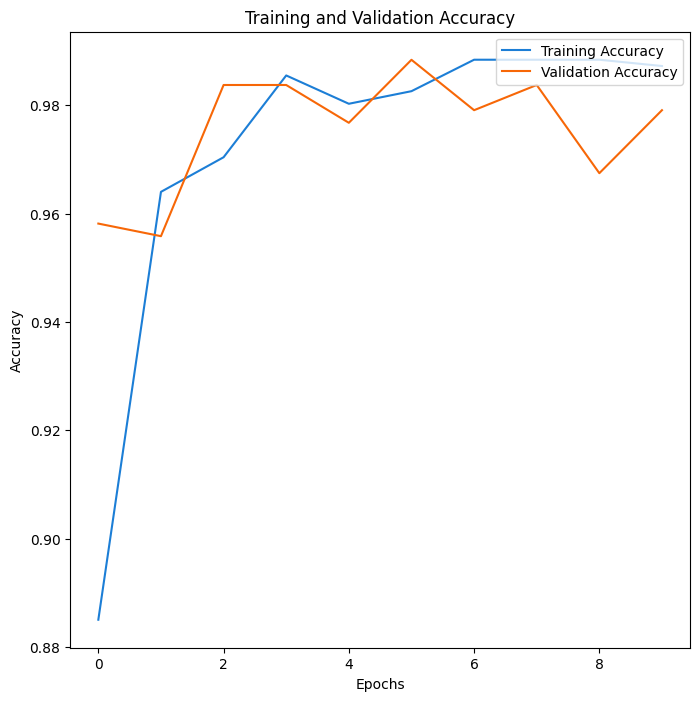

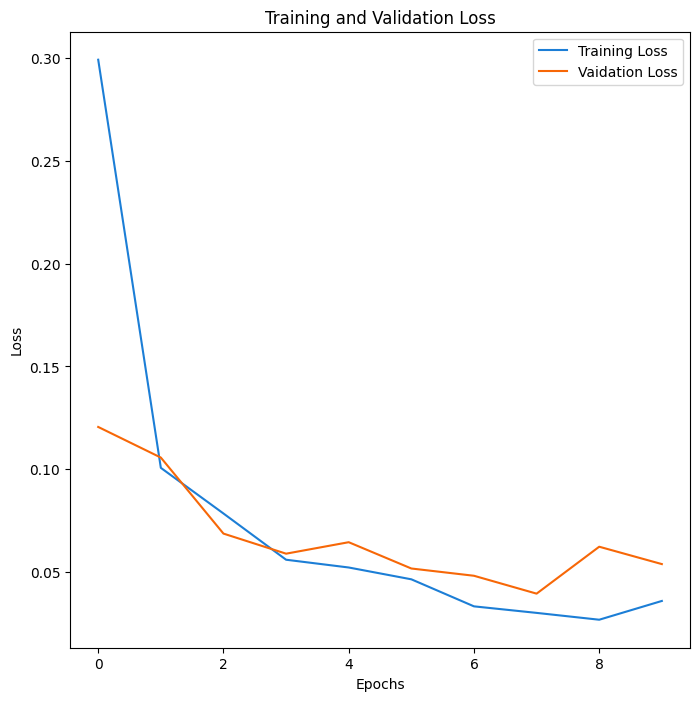

In [19]:
import matplotlib.pyplot as plt
acc= history.history["accuracy"]
val_acc=history.history["val_accuracy"]

acc_loss= history.history["loss"]
val_loss= history.history["val_loss"]
epochs= range(len(acc))

plt.figure(figsize=(8,8))
plt.plot(epochs, acc, label= "Training Accuracy", color= "#1c7ed6")
plt.plot(epochs, val_acc, label= "Validation Accuracy", color= "#f76707")
plt.title("Training and Validation Accuracy")
plt.legend(loc="upper right")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()


plt.figure(figsize=(8,8))
plt.plot(epochs, acc_loss, label= "Training Loss", color= "#1c7ed6")
plt.plot(epochs, val_loss, label= "Vaidation Loss", color= "#f76707")
plt.title("Training and Validation Loss")
plt.legend(loc="upper right")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Predictions shape: (32, 3)
Actual labels:    [0 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 1 1 0 0 0 0 1 1 1 2 0 1 0 1 0 0]
Predicted labels: [0 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 1 1 0 0 0 0 1 1 1 2 0 1 0 1 0 0]


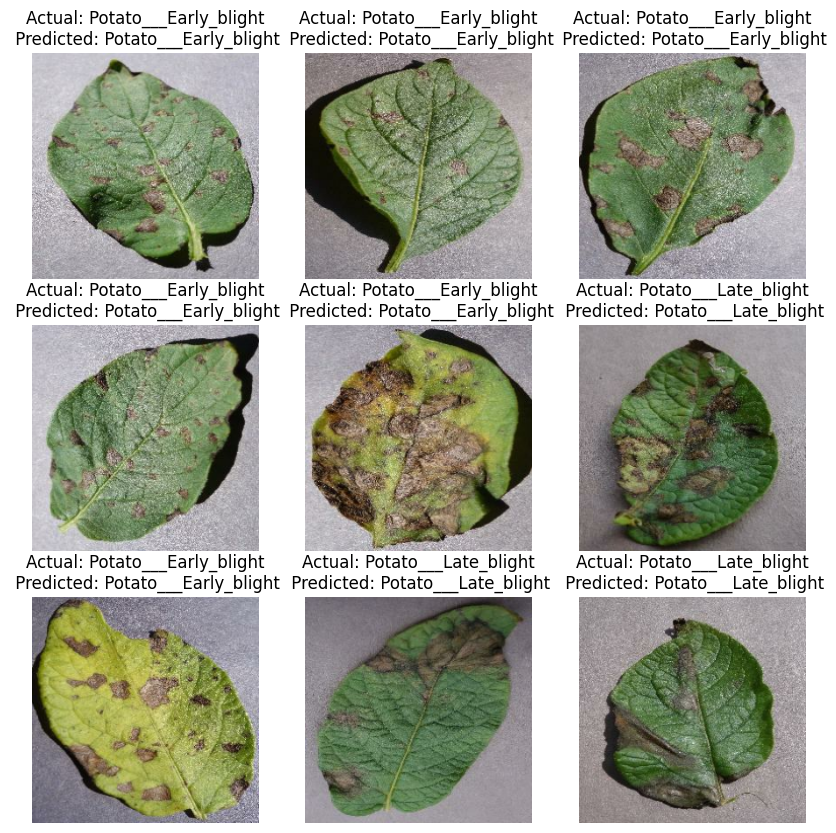

In [20]:
import numpy as np
for images, labels in val_data.take(1):
    model_predictions= model.predict(images)
    model_labels= np.argmax(model_predictions, axis=1)

    print(class_names)
    print("Predictions shape:", model_predictions.shape)
    # print("Predictions:", model_predictions)
    print("Actual labels:   ", labels.numpy())

    print("Predicted labels:", model_labels)
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax= plt.subplot(3,3, i+1)
        plt.imshow(images.numpy()[i].astype("uint8"))
        plt.title(f"Actual: {class_names[labels[i]]}\n Predicted: {class_names[model_labels[i]]}")
        plt.axis("off")


Image array shape: (224, 224, 3)
Expanded image array shape: (1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
(1, 3)
Predicted class: Potato___Early_blight
Confidence: 100.00%


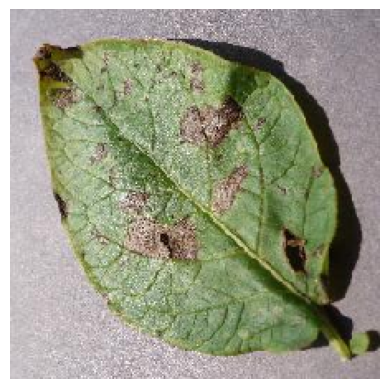

In [21]:
image_path="../datasets/Potato___Early_blight/0a8a68ee-f587-4dea-beec-79d02e7d3fa4___RS_Early.B 8461.JPG"
image_loaded=tf.keras.utils.load_img(image_path, target_size=(224,224))
plt.imshow(image_loaded)
plt.axis("off")

img_array= tf.keras.utils.img_to_array(image_loaded)
print("Image array shape:", img_array.shape)
img_array= np.expand_dims(img_array, axis=0)
print("Expanded image array shape:", img_array.shape)


predictions= model.predict(img_array)
confidence= np.max(predictions)*100
print(predictions.shape)
predicted_class= np.argmax(predictions, axis=1)
print(f"Predicted class: {class_names[predicted_class[0]]}")
print(f"Confidence: {confidence:.2f}%")

In [22]:
model.save("../model/plant_disease_mobilenet_model.keras")